In [ ]:
import anndata as ad
import matplotlib.pyplot as plt
# import rapids_singlecell as rsc
import seaborn as sns
import scanpy as sc
import pandas as pd
import numpy as np
import sys
import os

sys.path.append('../..')
import warnings
warnings.filterwarnings("ignore")

from models.evaluation.folds import load_existing_split
from models.clustering.correlations import *
from models.clustering.data_processing import *


from data_processing import *

In [ ]:
dataset            = 'LATTICeA_5x'

meta_field         = None
matching_field     = 'samples'
resolution         = 2.5
fold_number        = 2
groupby            = 'leiden_%s' % resolution
meta_folder        = 'rapids_2p5m'
folds_pickle       = './utilities/fold_creation/lattice_5x_folds.pkl'
additional_as_fold = False
h5_complete_path   = './results/BarlowTwins_3/LATTICeA_5x/h224_w224_n3_zdim128_filtered/hdf5_LATTICeA_5x_he_complete_filtered.h5'
h5_additional_path = None
Transform          = False

main_cluster_path = h5_complete_path.split('hdf5_')[0]
main_cluster_path = os.path.join(main_cluster_path, meta_folder)
adatas_path       = os.path.join(main_cluster_path, 'adatas')
figure_path       = os.path.join(main_cluster_path, 'leiden_%s_fold%s' % (str(resolution).replace('.','p'),fold_number))
figure_path       = os.path.join(figure_path,       'figures')
if not os.path.isdir(figure_path):
    os.makedirs(figure_path)

folds = load_existing_split(folds_pickle)
fold = folds[fold_number]

In [3]:
adata_train, h5ad_path = read_h5ad_reference(h5_complete_path, meta_folder, groupby, fold_number)

if os.path.isfile(h5ad_path.replace('.h5ad', '_paga_41.h5ad')):
    adata_train = ad.read_h5ad(h5ad_path.replace('.h5ad', '_paga_41.h5ad'))
else:
    rsc.tl.umap(adata_train, init_pos="spectral", neighbors_key='nn_leiden')
    adata_train.write(h5ad_path.replace('.h5ad', '_paga_41.h5ad'))

### UMAP - Leiden clusters

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


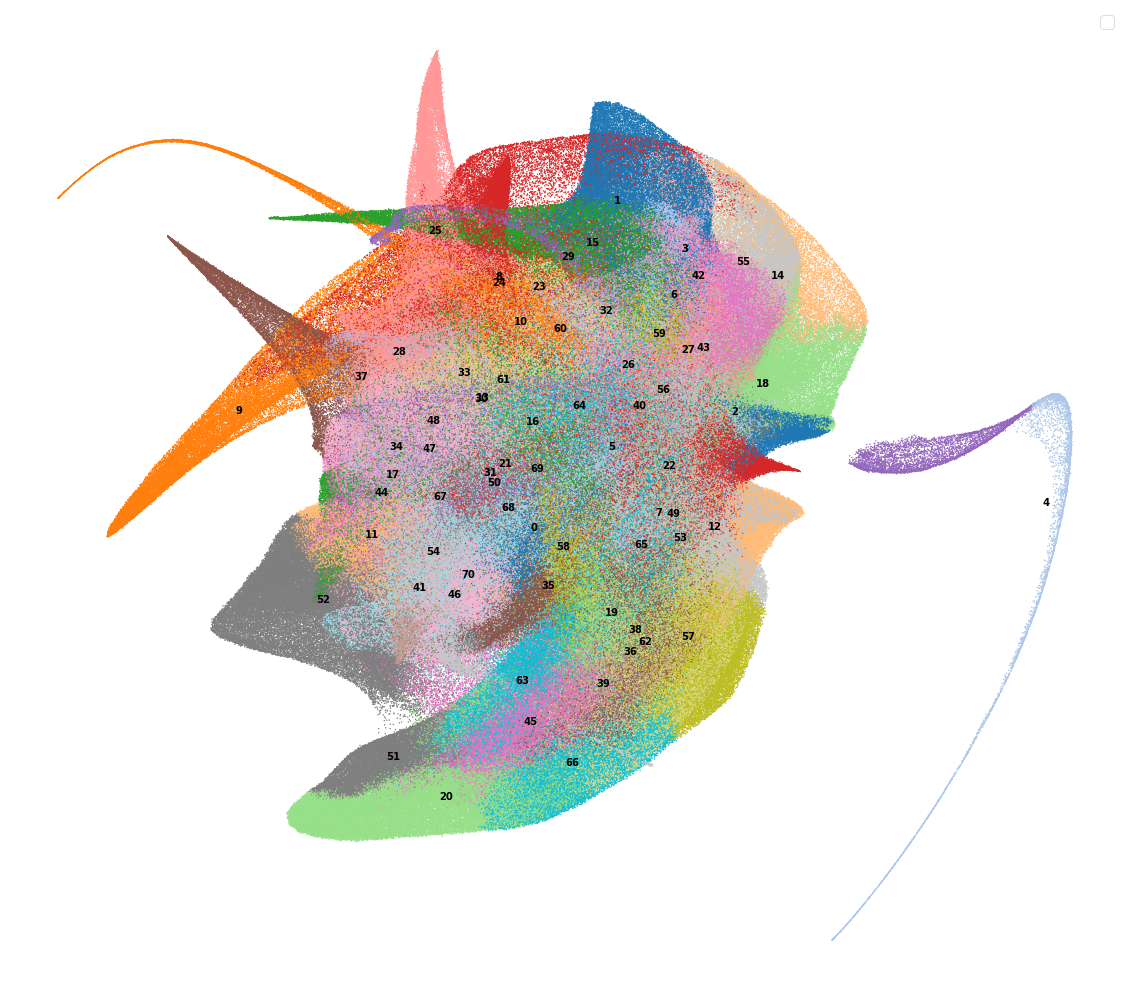

In [ ]:
sns.set_context('paper', font_scale=2.0)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20,18))
sc.pl.umap(adata_train, color=groupby, show=False, ax=ax, size=8, legend_loc='on data', palette='tab20')
ax.set_title(None)
ax.legend(loc='best', markerscale=1)

plt.axis('off')
plt.show()

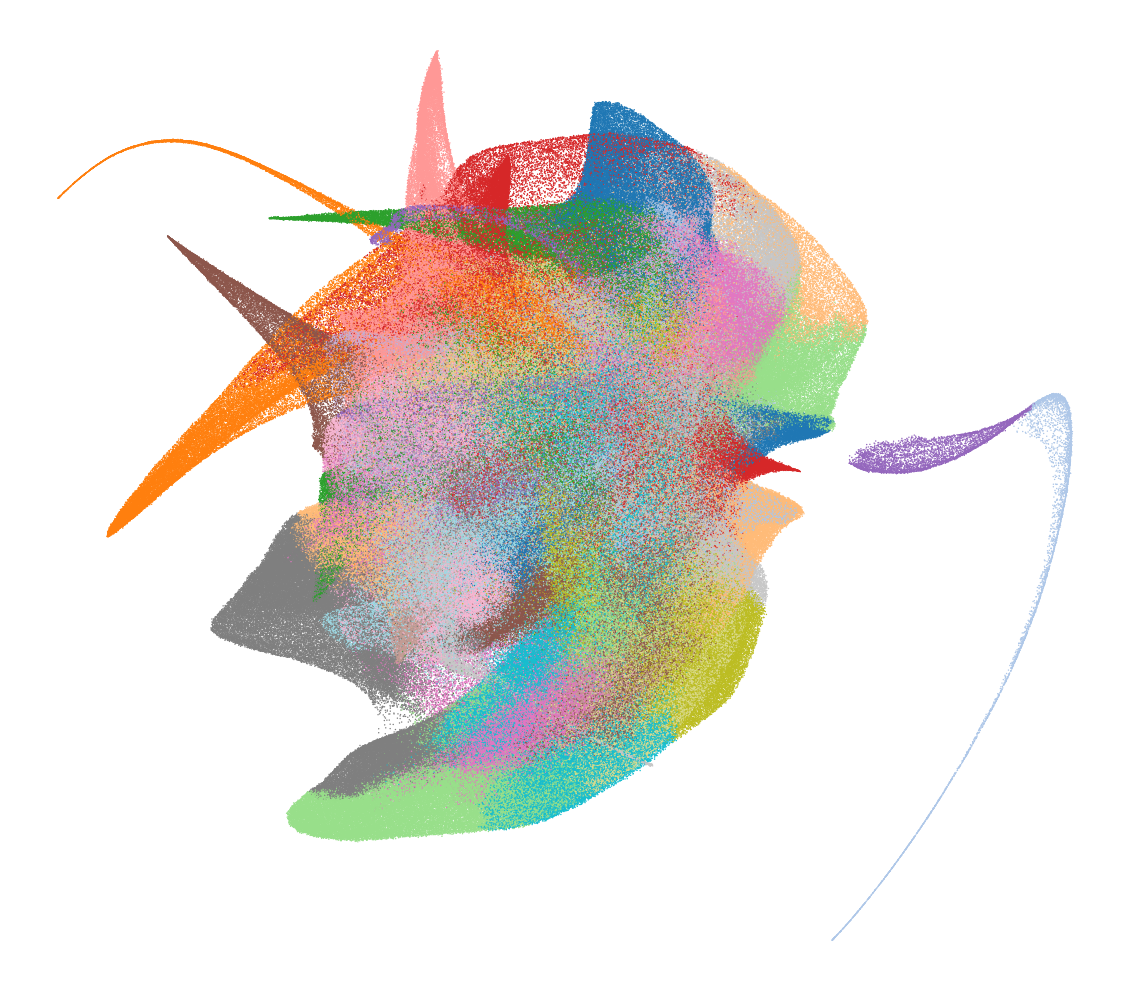

In [ ]:
sns.set_context('paper', font_scale=2.0)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20,18))
sc.pl.umap(adata_train, color=groupby, show=False, ax=ax, size=8, legend_loc=None, palette='tab20')
ax.set_title(None)

plt.axis('off')
plt.show()

### Consensus annotations

In [ ]:
annotations = pd.read_csv('./utilities/files/LUAD-LATTICeA/consensus_frame_JLQ_DD_KR.csv', index_col=0)
annotations['feature'] = annotations['feature'].apply(lambda x: x.capitalize())
annotations = annotations.fillna(0)
annotations['feature_category'] = 'Normal/non-neoplastic'
annotations['feature_category'] = annotations.apply(lambda row: 'Malignant' if row['malignant'] == 1 else row['feature_category'], axis=1)
annotations['feature_category'] = annotations.apply(lambda row: 'Stroma' if row['feature'] in ['Collagenosis', 'Elastosis', 'Lymphocytic Stroma', 'Other'] else row['feature_category'], axis=1)
annotations['feature_category'] = annotations.apply(lambda row: 'Necrosis' if row['feature'] == 'Necrosis' else row['feature_category'], axis=1)
annotations['stroma_epi_ratio'] = annotations['stroma_epi_ratio'].replace({1:'More epithelium', 2:'Roughly equal', 3:'More stroma'})
annotations['stroma_cellularity'] = annotations['stroma_cellularity'].replace({1:'Low', 2:'Moderate', 3:'High'})
annotations['inflammation'] = annotations['inflammation'].replace({1:'Low', 2:'Moderate', 3:'High'})


annotations

,cluster,malignant,feature,inflammation,necrosis,stroma_epi_ratio,stroma_cellularity,purity,description,free text,feature_category
0,0,1,Acinar,Moderate,1.0,Roughly equal,Moderate,3.0,0.0,0,Malignant
1,1,0,Collagenosis,Low,1.0,0.0,0.0,3.0,0.0,0,Stroma
2,2,0,Other,Moderate,1.0,0.0,0.0,3.0,0.0,Anthracosis,Stroma
3,3,0,Collagenosis,Low,1.0,0.0,0.0,3.0,0.0,0,Stroma
4,4,0,Cartilage,Low,1.0,0.0,0.0,3.0,0.0,0,Normal/non-neoplastic
...,...,...,...,...,...,...,...,...,...,...,...
66,66,0,Normal/near-normal lung,Low,1.0,0.0,0.0,3.0,0.0,0,Normal/non-neoplastic
67,67,1,Acinar,High,1.0,Roughly equal,Moderate,3.0,0.0,0,Malignant
68,68,1,Acinar,Moderate,1.0,Roughly equal,Moderate,3.0,0.0,0,Malignant
69,69,1,Acinar,Moderate,1.0,More stroma,Moderate,3.0,0.0,0,Malignant


In [7]:
adata_train.obs['consensus_feature'] = adata_train.obs['leiden_2.5'].apply(lambda x: annotations[annotations['cluster'].astype(str) == x]['feature'].values[0])
print('Patterns:', adata_train.obs['consensus_feature'].unique())

adata_train.obs['contain_tumour'] = adata_train.obs['leiden_2.5'].apply(lambda x: annotations[annotations['cluster'].astype(str) == x]['malignant'].values[0])
print('Tumoural:', adata_train.obs['contain_tumour'].unique())

adata_train.obs['stroma_epi_ratio'] = adata_train.obs['leiden_2.5'].apply(lambda x: str(annotations[annotations['cluster'].astype(str) == x]['stroma_epi_ratio'].values[0]))
adata_train.obs['stroma_epi_ratio'] = adata_train.obs['stroma_epi_ratio'].astype(str)
print('Stroma:epithelium ratio:', adata_train.obs['stroma_epi_ratio'].unique())

adata_train.obs['stroma_cellularity'] = adata_train.obs['leiden_2.5'].apply(lambda x: str(annotations[annotations['cluster'].astype(str) == x]['stroma_cellularity'].values[0]))
adata_train.obs['stroma_cellularity'] = adata_train.obs['stroma_cellularity'].astype(str)
print('Stromal cellularity:', adata_train.obs['stroma_cellularity'].unique())

adata_train.obs['inflammation'] = adata_train.obs['leiden_2.5'].apply(lambda x: str(annotations[annotations['cluster'].astype(str) == x]['inflammation'].values[0]))
adata_train.obs['inflammation'] = adata_train.obs['inflammation'].astype(str)
print('Inflammation:', adata_train.obs['inflammation'].unique())

adata_train.obs['feature_category'] = adata_train.obs['leiden_2.5'].apply(lambda x: annotations[annotations['cluster'].astype(str) == x]['feature_category'].values[0])
print('Feature categories:', adata_train.obs['feature_category'].unique())

Patterns: ['Normal/near-normal lung' 'Collagenosis' 'Lymphocytic stroma'
 'Cribriform' 'Non-neoplastic pathological lung' 'Solid' 'Elastosis'
 'Acinar' 'Necrosis' 'Lepidic' 'Papillary' 'Airways'
 'Papillary/micropapillary' 'Vessel (wall or lumen)' 'Other' 'Cartilage']
Tumoural: [0 1]
Stroma:epithelium ratio: ['0.0' 'More stroma' 'More epithelium' 'Roughly equal']
Stromal cellularity: ['0.0' 'Moderate' 'High' 'Low']
Inflammation: ['Moderate' 'High' 'Low']
Feature categories: ['Normal/non-neoplastic' 'Stroma' 'Malignant' 'Necrosis']


In [8]:
adata_train.obs['inflammation'] = pd.Categorical(
    adata_train.obs['inflammation'],
    categories=['Low', 'Moderate', 'High'],
    ordered=True
)


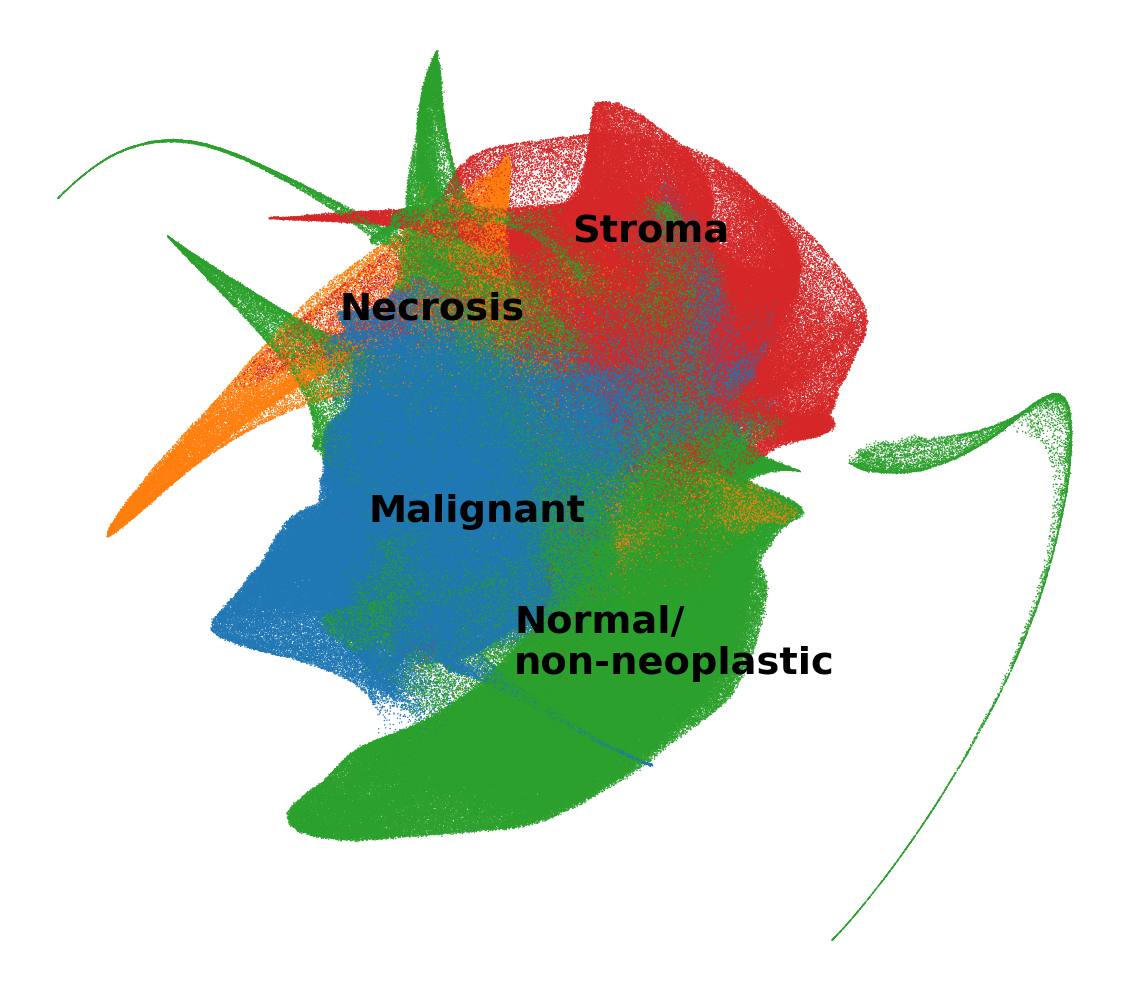

In [ ]:
sns.set_context('paper', font_scale=4.0)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20,18))

sc.pl.umap(adata_train, color='feature_category', show=False, ax=ax, size=8, legend_loc=None, cmap='Set2')
ax.set_title(None)

ax.text(x=-7, y=6, s='Necrosis', fontdict={'fontweight':'bold'})
ax.text(x=-1, y=-8, s='Normal/\nnon-neoplastic', fontdict={'fontweight':'bold'})
ax.text(x=-6, y=-2, s='Malignant', fontdict={'fontweight':'bold'})
ax.text(x=1, y=9, s='Stroma', fontdict={'fontweight':'bold'})

plt.axis('off')
plt.show()

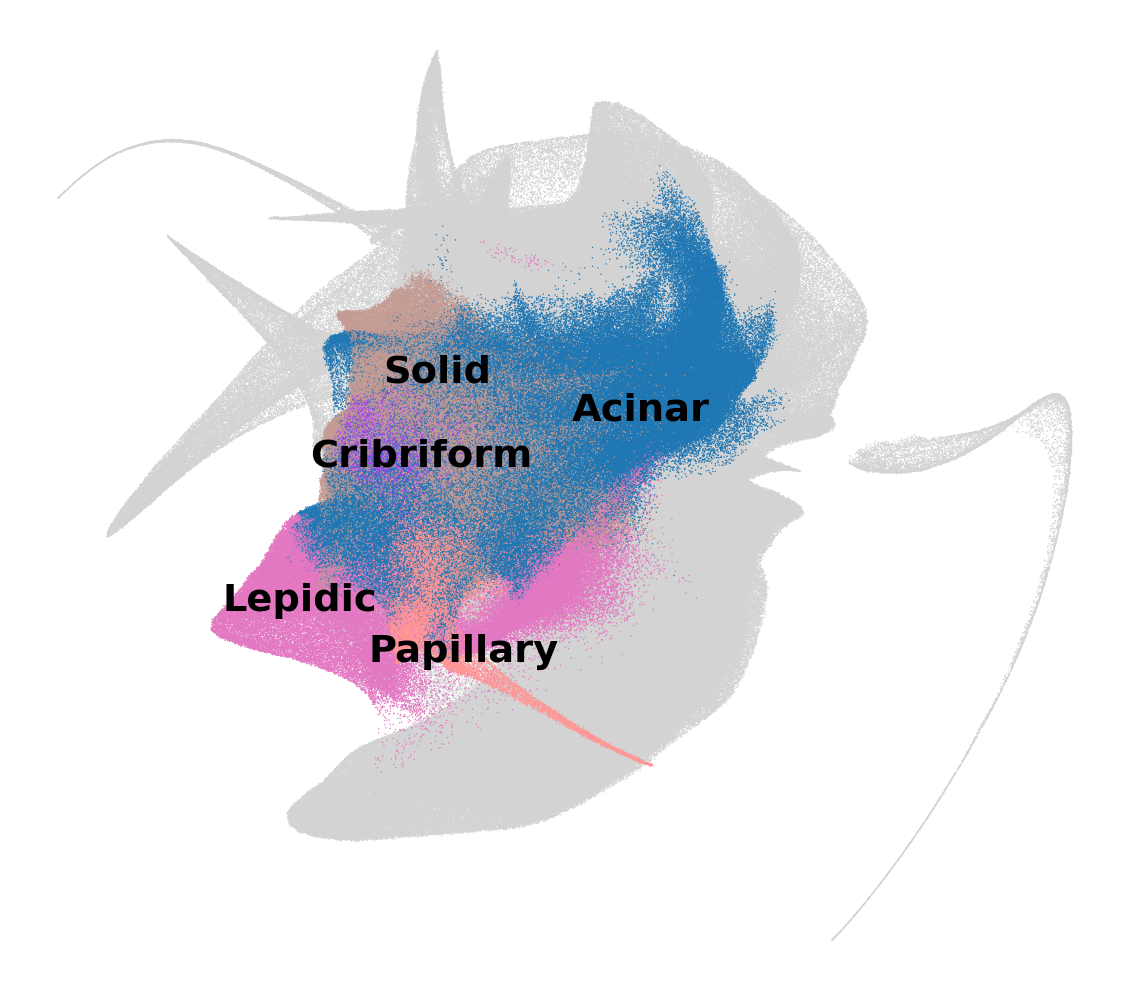

In [ ]:
sns.set_context('paper', font_scale=4.0)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20,18))

sc.pl.umap(adata_train, color='consensus_feature', show=False, ax=ax, size=8, legend_loc=None, cmap='Set2', groups=['Lepidic', 'Acinar', 'Papillary', 'Cribriform', 'Solid', 'Micropapillary'], na_in_legend=False)
ax.set_title(None)
ax.text(s='Lepidic', x=-11, y=-5.5, fontdict={'fontweight':'bold'})
ax.text(s='Papillary', x=-6.0, y=-7.5, fontdict={'fontweight':'bold'})
ax.text(s='Cribriform', x=-8, y=0.2, fontdict={'fontweight':'bold'})
ax.text(s='Solid', x=-5.5, y=3.5, fontdict={'fontweight':'bold'})
ax.text(s='Acinar', x=1.0, y=2, fontdict={'fontweight':'bold'})
plt.axis('off')

plt.show()

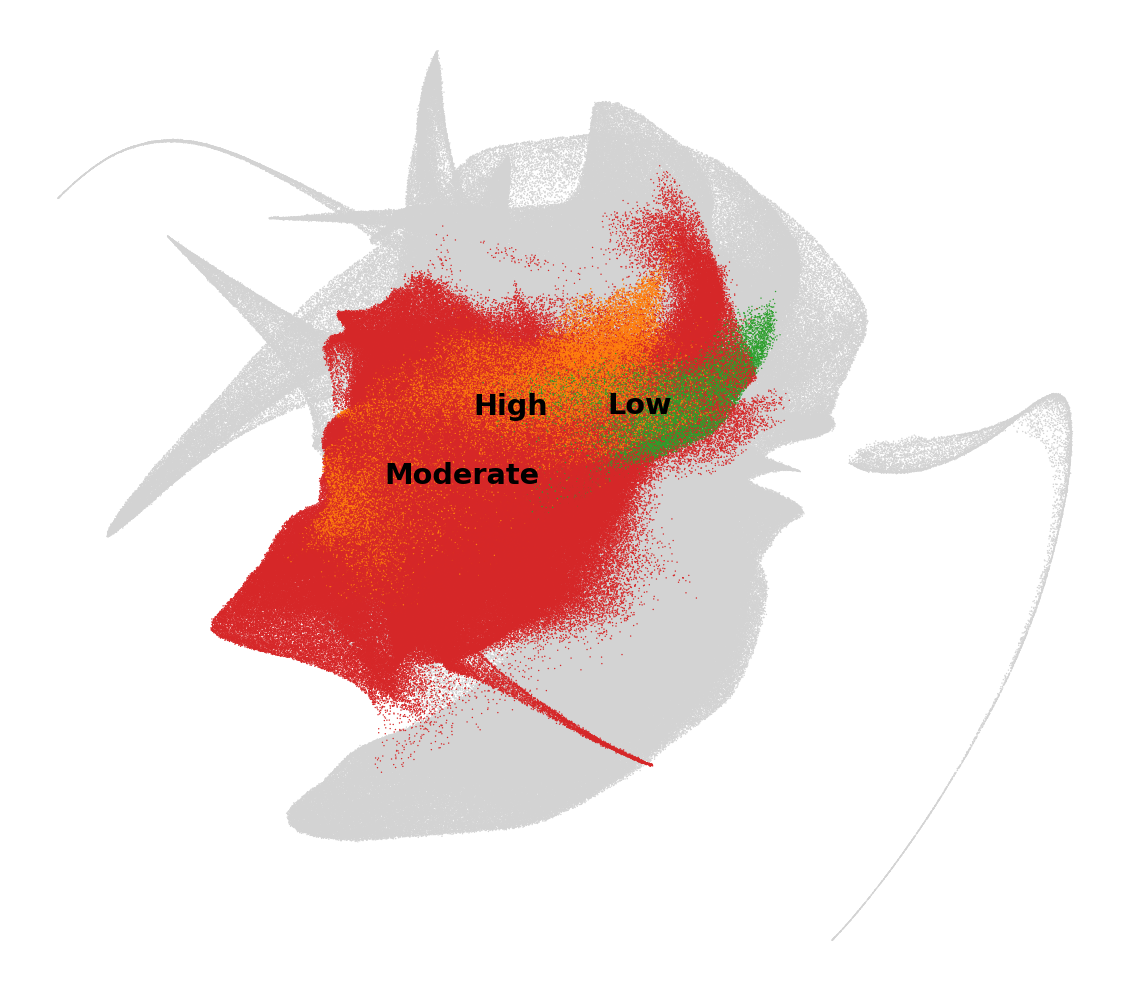

In [ ]:
sns.set_context('paper', font_scale=3.0)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20,18))

sc.pl.umap(adata_train, color='stroma_cellularity', show=False, ax=ax, size=8, groups=['Low', 'Moderate', 'High'], na_in_legend=False, legend_loc='on data', cmap='Set2')
ax.set_title(None)
plt.axis('off')
plt.show()

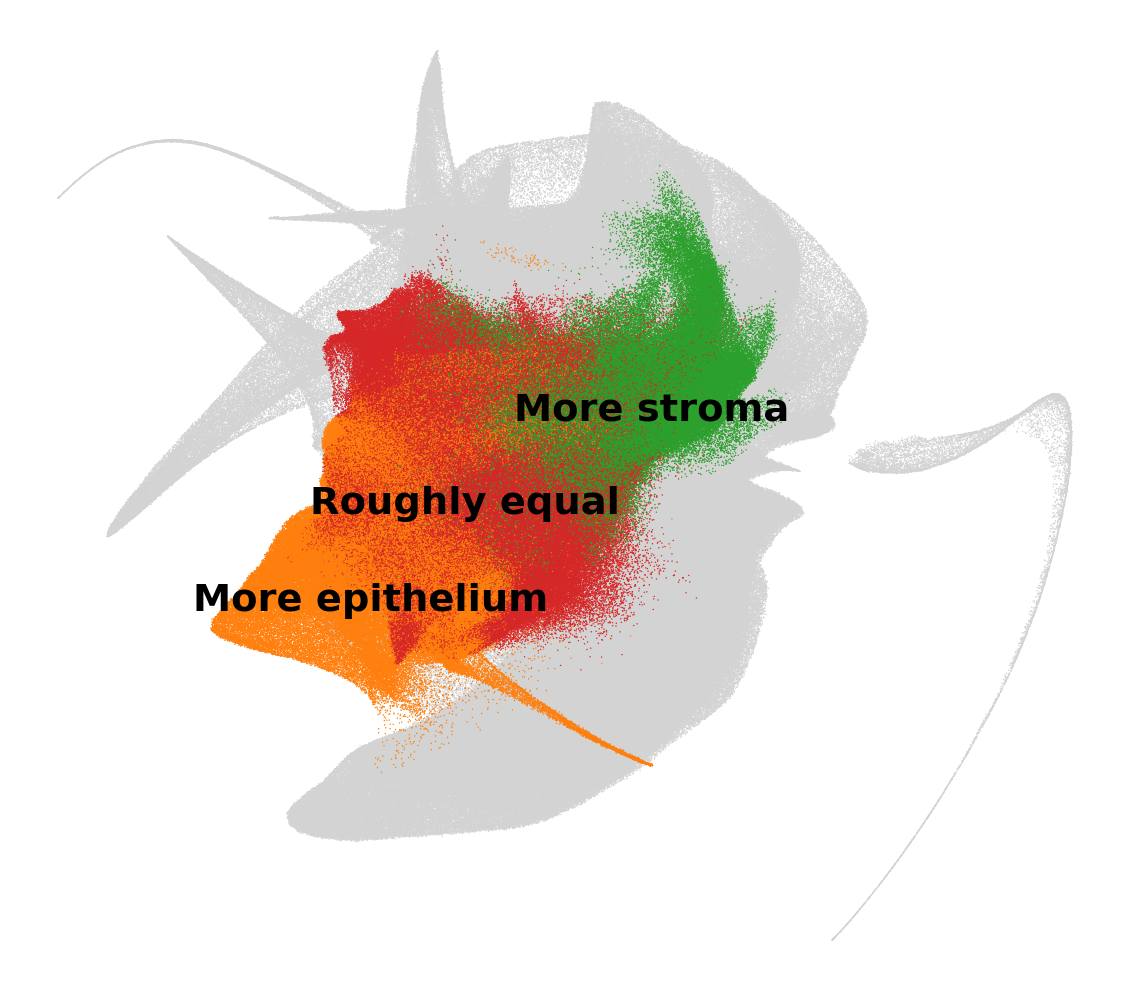

In [ ]:
sns.set_context('paper', font_scale=4.0)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20,18))

sc.pl.umap(adata_train, color='stroma_epi_ratio', show=False, ax=ax, size=8, groups=['More epithelium', 'Roughly equal', 'More stroma'], na_in_legend=False, legend_loc=None, cmap='Set2')
ax.set_title(None)

ax.text(s='More epithelium', x=-12, y=-5.5, fontdict={'fontweight':'bold'})
ax.text(s='Roughly equal', x=-8, y=-1.7, fontdict={'fontweight':'bold'})
ax.text(s='More stroma', x=-1.0, y=2, fontdict={'fontweight':'bold'})

plt.axis('off')
plt.show()

In [41]:
adata_train.obs['inflammation'] = adata_train.obs['inflammation'].replace()

3351228    2
599197     2
373088     3
4218406    2
1904584    2
          ..
2749700    1
4617051    1
956274     2
2737388    2
421760     2
Name: inflammation, Length: 2500000, dtype: int64

In [53]:
adata_train.obs['inflammation']

3351228    Moderate
599197     Moderate
373088         High
4218406    Moderate
1904584    Moderate
             ...   
2749700         Low
4617051         Low
956274     Moderate
2737388    Moderate
421760     Moderate
Name: inflammation, Length: 2500000, dtype: category
Categories (3, object): ['Low' < 'Moderate' < 'High']

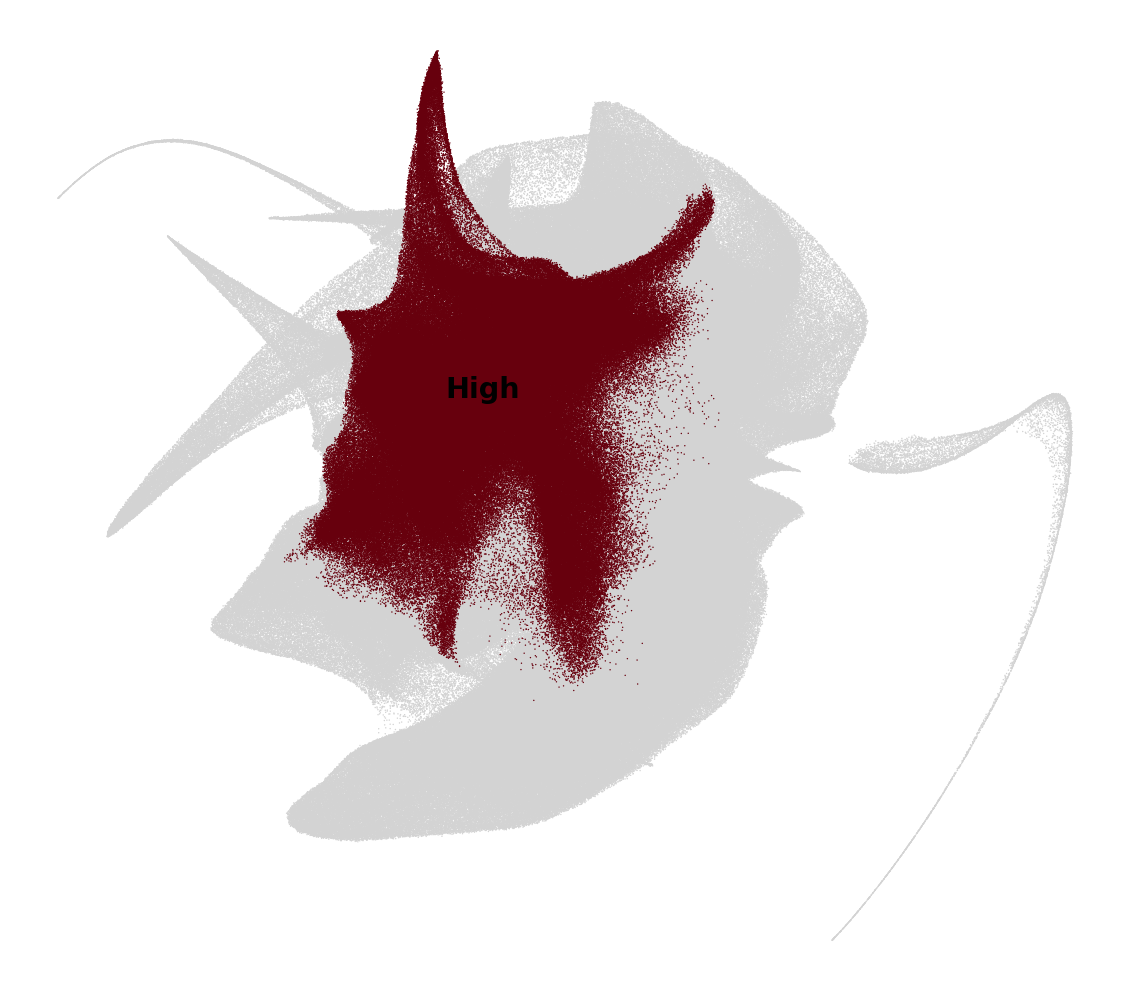

In [ ]:
sns.set_context('paper', font_scale=3.0)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20,18))

sc.pl.umap(adata_train, color='inflammation', show=False, ax=ax, size=8, na_in_legend=False, legend_loc='on data', palette='Reds', sort_order=True, groups=['High'])
ax.set_title(None)
plt.axis('off')
plt.show()

### Superclusters

In [ ]:
cluster_annotations = pd.read_csv('./merged_cluster_lym_log10_density_and_noise.csv')
cluster_annotations

,Unnamed: 0,Supercluster,HPC,noise,robust_z_score_x,median_x,CKPAN,SMA,Negative,CD4,CD68,CD8,lym,robust_z_score_y,median_y
0,0,Hot cohesive,HPC 0,0.030344,-0.398536,0,3.458759,3.042304,1208.949339,3.092664,2.676937,2.587051,3.247579,0.269873,1
1,1,Cold cohesive,HPC 11,0.025816,-0.489230,0,3.537818,2.678664,1141.304331,2.837660,2.645275,2.453921,3.020685,-0.416745,0
2,2,Hot discohesive,HPC 13,0.088962,0.775638,1,3.376048,2.875556,1080.732825,3.052229,2.809495,2.732999,3.250600,0.279017,1
3,3,Hot discohesive,HPC 16,0.215348,3.307301,1,3.119559,3.016854,2125.246560,3.271159,2.916385,3.294004,3.602642,1.344358,1
4,4,Cold cohesive,HPC 17,0.008196,-0.842181,0,3.686496,2.845440,1037.222203,2.978421,2.584696,2.314590,3.053223,-0.318280,0
5,5,Cold cohesive,HPC 21,0.024876,-0.508074,0,3.503920,2.830604,1566.409993,2.785833,2.625204,2.252343,2.961775,-0.595019,0
6,6,Cold discohesive,HPC 27,0.154209,2.082626,1,3.120690,3.012635,1607.224329,2.625153,2.678300,2.490447,2.968499,-0.574672,0
7,7,Hot discohesive,HPC 28,0.085580,0.707910,1,3.224591,2.836164,2142.051194,3.403758,2.911226,3.056120,3.558568,1.210980,1
8,8,Cold discohesive,HPC 30,0.080967,0.615499,1,3.378119,2.727039,957.674492,2.685309,2.737602,2.307740,2.887261,-0.820510,0
9,9,Cold discohesive,HPC 31,0.068879,0.373365,1,3.329674,2.872341,1604.931778,2.801328,2.681267,2.618584,3.127121,-0.094653,0


In [9]:
def assign_supercluster_(x):
    try:
        return cluster_annotations[cluster_annotations['HPC'] == f'HPC {x}']['Supercluster'].values[0]
    except IndexError:
        return np.nan

adata_train.obs['supercluster'] = adata_train.obs['leiden_2.5'].apply(lambda x: assign_supercluster_(x))
print('Superclusters:', adata_train.obs['supercluster'].unique())

Superclusters: [nan 'Hot discohesive' 'Cold cohesive' 'Hot cohesive' 'Cold discohesive']


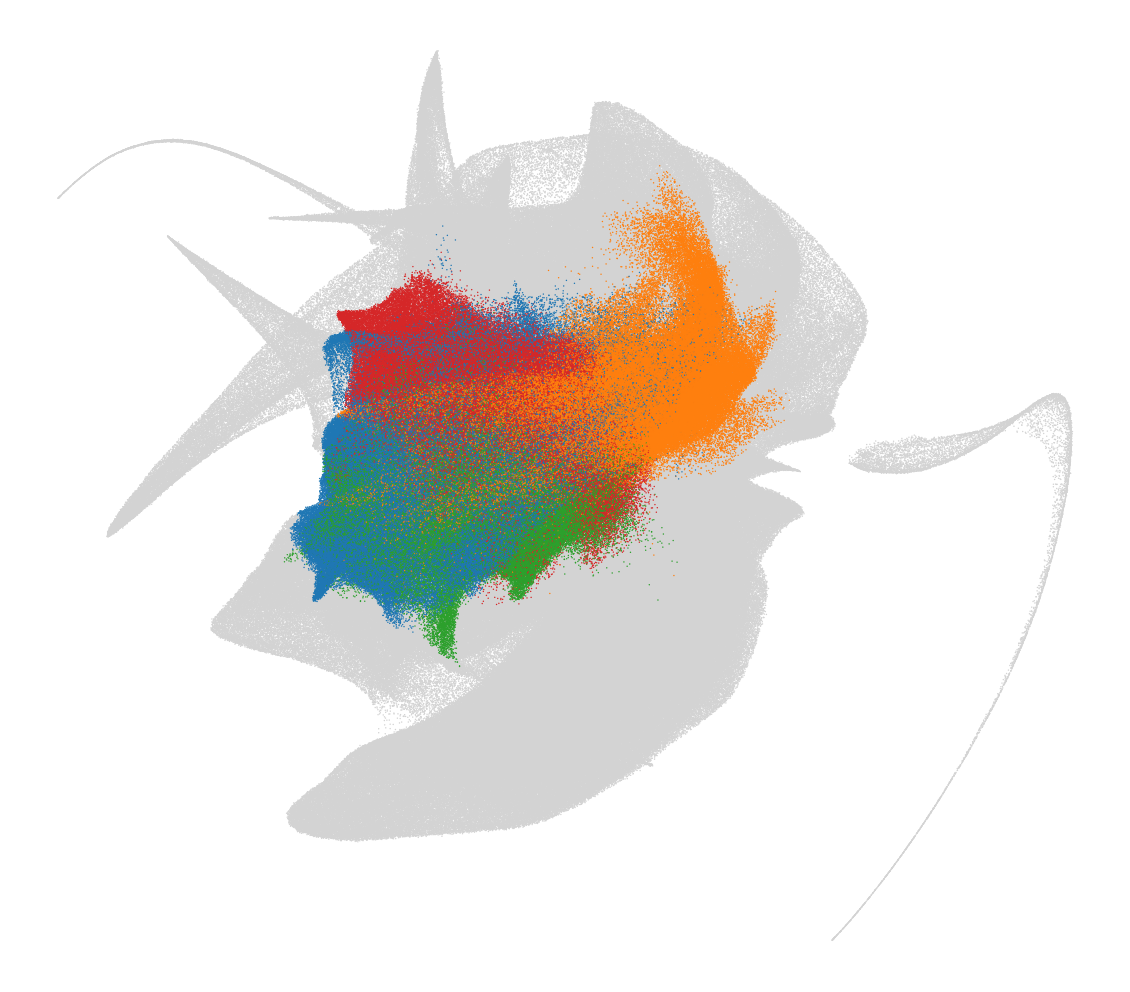

In [ ]:
sns.set_context('paper', font_scale=3.0)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20,18))

sc.pl.umap(adata_train, color='supercluster', show=False, ax=ax, size=8, groups=['Hot discohesive', 'Cold cohesive', 'Hot cohesive', 'Cold discohesive'], na_in_legend=False, legend_loc=None, cmap='Set2')
ax.set_title(None)
plt.axis('off')
plt.show()

### Hazard ratios

In [59]:
sys.path.append('/nfs/home/users/krakovic/sharedscratch/notebooks/latticea_he/libraries/')
from data_processing import *

hazard_ratios = load_hazard_ratios(which='malignant')
hazard_ratios = hazard_ratios.rename(columns={'covariate':'HPC'})
hazard_ratios

,HPC,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,z,p,-log2(p),se
0,HPC 69,-9.143486e-02,0.912728,0.060699,-0.210477,0.027607,0.810411,1.027981,-1.499727,2.642909e-02,2.930518,0.060737
1,HPC 0,-6.340027e-02,0.938595,0.035422,-0.132961,0.006160,0.875644,1.006090,-1.800771,2.956458e-03,3.844942,0.035491
2,HPC 48,-3.259174e-02,0.967962,0.037511,-0.106142,0.040958,0.899348,1.041816,-0.871419,4.612673e-01,1.408920,0.037526
3,HPC 61,-1.462880e-02,0.985505,0.049015,-0.110712,0.081455,0.895246,1.084868,-0.296521,9.871847e-01,0.393065,0.049023
4,HPC 11,-1.302853e-02,0.987125,0.025089,-0.068028,0.041971,0.940197,1.037032,-0.418622,9.261412e-01,0.638402,0.028061
5,HPC 34,-9.902549e-03,0.990241,0.027146,-0.069365,0.049560,0.939371,1.044608,-0.303271,9.704989e-01,0.490000,0.030339
6,HPC 67,-1.217854e-03,0.998786,0.007250,-0.032635,0.030199,0.985140,1.013413,-0.033915,9.999995e-01,0.042297,0.016029
7,HPC 50,-2.099341e-07,1.000000,0.000305,-0.000757,0.000756,0.999402,1.000598,-0.000591,1.000000e+00,0.000768,0.000386
8,HPC 28,1.534842e-08,1.000000,0.000115,-0.000228,0.000228,0.999774,1.000226,0.000171,1.000000e+00,0.000820,0.000116
9,HPC 54,6.282187e-04,1.000632,0.014429,-0.043893,0.045149,0.973278,1.029973,0.018307,9.999990e-01,0.048770,0.022715


In [60]:
adata_train.obs['HPC'] = adata_train.obs['leiden_2.5'].apply(lambda x: 'HPC ' + str(x))
adata_train.obs = adata_train.obs.merge(hazard_ratios[['HPC', 'exp(coef)']], on='HPC', how='left')
adata_train.obs = adata_train.obs.rename(columns={'exp(coef)':'malignant_hazard_ratio_exp'})
adata_train.obs

,has_recurrence,hist_subtype,indexes,labels,li,male,original_set,os_event_data,os_event_ind,patterns,...,vi,leiden_2.5,consensus_feature,contain_tumour,stroma_epi_ratio,stroma_cellularity,inflammation,feature_category,HPC,malignant_hazard_ratio_exp
0,1,tiled_images_5,4528043,0.0,0.0,1,train,113.1616438,1,tiled_images_5,...,0.0,63,Normal/near-normal lung,0,0.0,0.0,Moderate,Normal/non-neoplastic,HPC 63,NaN
1,1,tiled_images_5,810093,0.0,0.0,0,train,18.44383562,1,tiled_images_5,...,1.0,56,Collagenosis,0,0.0,0.0,Moderate,Stroma,HPC 56,NaN
2,1,tiled_images_5,504174,0.0,0.0,1,train,42.31232877,0,tiled_images_5,...,0.0,16,Lymphocytic stroma,0,More stroma,Moderate,High,Normal/non-neoplastic,HPC 16,NaN
3,1,tiled_images_5,149614,0.0,0.0,0,valid,34.32328767,1,tiled_images_5,...,0.0,34,Cribriform,1,More epithelium,Moderate,Moderate,Malignant,HPC 34,0.990241
4,1,tiled_images_5,2572634,0.0,1.0,1,train,53.35890411,0,tiled_images_5,...,0.0,70,Non-neoplastic pathological lung,0,0.0,0.0,Moderate,Normal/non-neoplastic,HPC 70,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2499995,1,tiled_images_5,3715277,0.0,0.0,0,train,38.59726027,0,tiled_images_5,...,0.0,23,Elastosis,0,0.0,0.0,Low,Stroma,HPC 23,NaN
2499996,1,tiled_images_5,671925,0.0,0.0,1,valid,0.295890411,1,tiled_images_5,...,0.0,27,Acinar,1,More stroma,Moderate,Low,Malignant,HPC 27,1.120559
2499997,1,tiled_images_5,1292681,0.0,1.0,1,train,53.35890411,0,tiled_images_5,...,0.0,70,Non-neoplastic pathological lung,0,0.0,0.0,Moderate,Normal/non-neoplastic,HPC 70,NaN
2499998,1,tiled_images_5,3698670,0.0,0.0,0,train,77.22739726,1,tiled_images_5,...,1.0,19,Normal/near-normal lung,0,0.0,0.0,Moderate,Normal/non-neoplastic,HPC 19,NaN


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


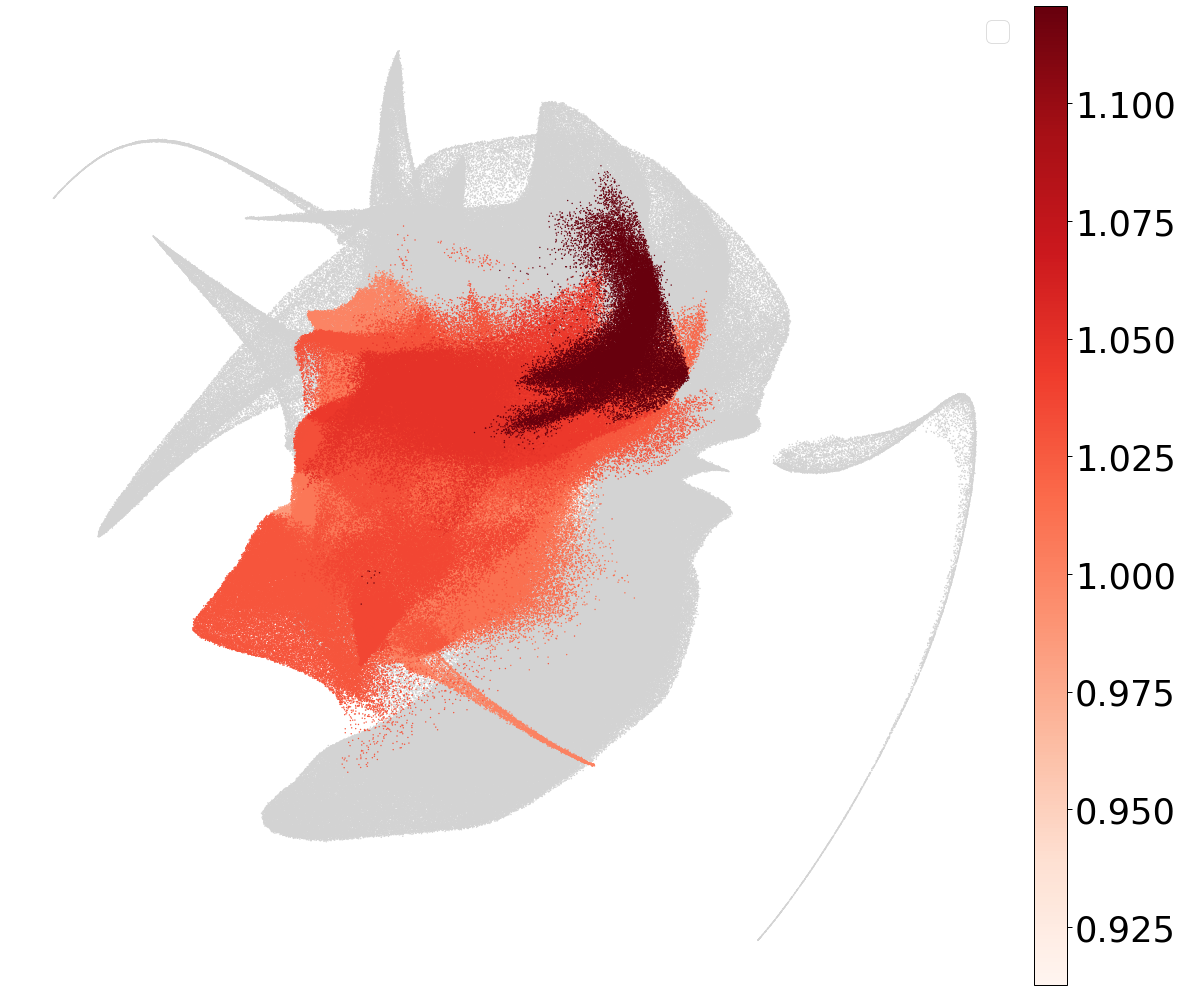

In [ ]:
sns.set_context('paper', font_scale=4.0)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20,18))
# sns.set_theme(style='white')

sc.pl.umap(adata_train, color='malignant_hazard_ratio_exp', show=False, ax=ax, size=8, legend_loc='on data', groups=list(hazard_ratios['HPC']), cmap='Reds')
legend_c = ax.legend(loc='best', markerscale=1, prop={'size': 28});
legend_c.get_title().set_fontsize(15)
ax.set_title(None)
plt.axis('off')
plt.show()